In [10]:
# IMPORTS

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random

In [11]:
# FUZZY MEMBERSHIP FUNCTIONS

def triangular(x, a, b, c):
    """Triangular membership function."""
    if x <= a or x >= c:
        return 0.0

    if x == b:
        return 1.0

    if x < b:
        return (x - a) / (b - a)

    return (c - x) / (c - b)


def trapezoidal(x, a, b, c, d):
    """Trapezoidal membership function."""
    if x <= a or x >= d:
        return 0.0

    if b <= x <= c:
        return 1.0

    if x < b:
        return (x - a) / (b - a)

    return (d - x) / (d - c)

In [12]:
# FUZZY STATE REPRESENTATION

class FuzzyState:

    def __init__(self, membership_type="triangular", num_sets=3):
        self.membership_type = membership_type
        self.num_sets = num_sets

    def membership(self, x, minimum, maximum):
        # Normalize x between 0 and 1.
        x = np.clip(
            (x - minimum) / (maximum - minimum),
            0,
            1
        )

        if self.num_sets == 2:
            if self.membership_type == "triangular":
                left = max(0, 1 - 2 * x)
                right = max(0, 2 * x - 1)
            else:
                left = 1 if x <= 0.5 else 0
                right = 1 if x >= 0.5 else 0

            return np.array([left, right])

        if self.num_sets == 5:
            if self.membership_type == "triangular":
                sets = [
                    triangular(x, 0.0, 0.0, 0.25),
                    triangular(x, 0.0, 0.25, 0.5),
                    triangular(x, 0.25, 0.5, 0.75),
                    triangular(x, 0.5, 0.75, 1.0),
                    triangular(x, 0.75, 1.0, 1.0)
                ]
            else:
                sets = [
                    trapezoidal(x, 0.0, 0.0, 0.15, 0.3),
                    trapezoidal(x, 0.1, 0.25, 0.35, 0.5),
                    trapezoidal(x, 0.3, 0.45, 0.55, 0.7),
                    trapezoidal(x, 0.5, 0.65, 0.75, 0.9),
                    trapezoidal(x, 0.7, 0.85, 1.0, 1.0)
                ]

            return np.array(sets)

        if self.membership_type == "triangular":
            sets = [
                triangular(x, 0.0, 0.0, 0.5),
                triangular(x, 0.0, 0.5, 1.0),
                triangular(x, 0.5, 1.0, 1.0)
            ]
        else:
            sets = [
                trapezoidal(x, 0.0, 0.0, 0.2, 0.5),
                trapezoidal(x, 0.2, 0.4, 0.6, 0.8),
                trapezoidal(x, 0.5, 0.8, 1.0, 1.0)
            ]

        return np.array(sets)

    def fuzzify(self, state):
        cart_position = state[0]
        cart_velocity = state[1]
        pole_angle = state[2]
        pole_velocity = state[3]

        variables = [
            (cart_position, -2.4, 2.4),
            (cart_velocity, -3.0, 3.0),
            (pole_angle, -0.2095, 0.2095),
            (pole_velocity, -3.5, 3.5)
        ]

        memberships = []
        for value, minimum, maximum in variables:
            memberships.append(
                np.argmax(self.membership(value, minimum, maximum))
            )

        return tuple(memberships)

In [13]:
# FUZZY Q-LEARNING AGENT

class FuzzyQLearningAgent:

    def __init__(
        self,
        num_sets=3,
        membership_type="triangular",
        alpha=0.1,
        gamma=0.9,
        epsilon=1.0,
        epsilon_decay=0.995,
        epsilon_min=0.01
    ):
        self.num_sets = num_sets
        self.membership_type = membership_type
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.actions = [0, 1]

        self.fuzzy = FuzzyState(membership_type, num_sets)
        number_of_states = num_sets ** 4
        self.q_table = np.zeros((number_of_states, len(self.actions)))

    def state_to_index(self, fuzzy_state):
        index = 0
        for value in fuzzy_state:
            index = index * self.num_sets + value
        return index

    def choose_action(self, state):
        fuzzy_state = self.fuzzy.fuzzify(state)
        state_index = self.state_to_index(fuzzy_state)

        if random.random() < self.epsilon:
            return random.choice(self.actions)

        return np.argmax(self.q_table[state_index])

    def update(self, state, action, reward, next_state, done):
        fuzzy_state = self.fuzzy.fuzzify(state)
        next_fuzzy_state = self.fuzzy.fuzzify(next_state)
        state_index = self.state_to_index(fuzzy_state)
        next_state_index = self.state_to_index(next_fuzzy_state)
        current_q = self.q_table[state_index, action]

        if done:
            target = reward
        else:
            target = reward + self.gamma * np.max(self.q_table[next_state_index])

        self.q_table[state_index, action] = (
            current_q + self.alpha * (target - current_q)
        )

    def decay_epsilon(self):
        self.epsilon = max(
            self.epsilon_min,
            self.epsilon * self.epsilon_decay
        )

In [14]:
# TRAINING

def train(
    episodes=1000,
    num_sets=3,
    membership_type="triangular",
    alpha=0.1,
    gamma=0.9
):
    env = gym.make("CartPole-v1")

    agent = FuzzyQLearningAgent(
        num_sets=num_sets,
        membership_type=membership_type,
        alpha=alpha,
        gamma=gamma
    )

    rewards = []

    for episode in range(episodes):
        state, info = env.reset()
        total_reward = 0
        done = False

        while not done:
            action = agent.choose_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            agent.update(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward

        agent.decay_epsilon()
        rewards.append(total_reward)

        if (episode + 1) % 100 == 0:
            average = np.mean(rewards[-100:])
            print(
                f"Episode {episode + 1}, "
                f"Average Reward = {average:.2f}, "
                f"Epsilon = {agent.epsilon:.3f}"
            )

    env.close()
    return rewards

In [15]:
# PLOT RESULTS

def plot_rewards(rewards, title):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards, alpha=0.4)

    if len(rewards) >= 50:
        moving_average = np.convolve(
            rewards,
            np.ones(50) / 50,
            mode="valid"
        )
        plt.plot(range(49, len(rewards)), moving_average)

    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title(title)
    plt.grid()
    plt.show()

Episode 100, Average Reward = 22.68, Epsilon = 0.606
Episode 200, Average Reward = 15.10, Epsilon = 0.367
Episode 300, Average Reward = 13.22, Epsilon = 0.222
Episode 400, Average Reward = 11.52, Epsilon = 0.135
Episode 500, Average Reward = 10.44, Epsilon = 0.082
Episode 600, Average Reward = 10.47, Epsilon = 0.049
Episode 700, Average Reward = 10.11, Epsilon = 0.030
Episode 800, Average Reward = 10.01, Epsilon = 0.018
Episode 900, Average Reward = 9.97, Epsilon = 0.011
Episode 1000, Average Reward = 10.05, Epsilon = 0.010


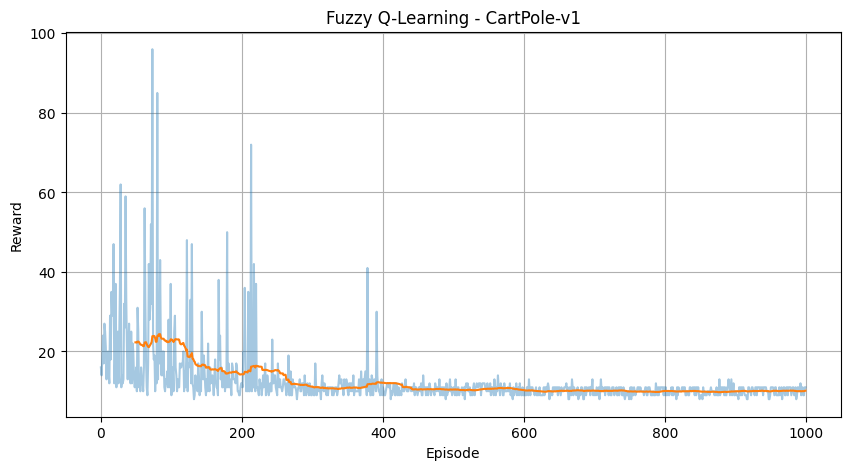

In [16]:
# MAIN

rewards = train(
    episodes=1000,
    num_sets=3,
    membership_type="triangular",
    alpha=0.1,
    gamma=0.9
)

plot_rewards(
    rewards,
    "Fuzzy Q-Learning - CartPole-v1"
)

Episode 100, Average Reward = 20.27, Epsilon = 0.606
Episode 200, Average Reward = 17.14, Epsilon = 0.367
Episode 300, Average Reward = 12.38, Epsilon = 0.222
Episode 400, Average Reward = 11.66, Epsilon = 0.135
Episode 500, Average Reward = 10.54, Epsilon = 0.082
Episode 600, Average Reward = 10.45, Epsilon = 0.049
Episode 700, Average Reward = 10.50, Epsilon = 0.030
Episode 800, Average Reward = 10.05, Epsilon = 0.018
Episode 900, Average Reward = 10.00, Epsilon = 0.011
Episode 1000, Average Reward = 10.36, Epsilon = 0.010
Episode 100, Average Reward = 20.91, Epsilon = 0.606
Episode 200, Average Reward = 21.18, Epsilon = 0.367
Episode 300, Average Reward = 26.04, Epsilon = 0.222
Episode 400, Average Reward = 28.65, Epsilon = 0.135
Episode 500, Average Reward = 47.09, Epsilon = 0.082
Episode 600, Average Reward = 49.08, Epsilon = 0.049
Episode 700, Average Reward = 48.74, Epsilon = 0.030
Episode 800, Average Reward = 64.71, Epsilon = 0.018
Episode 900, Average Reward = 86.36, Epsilon 

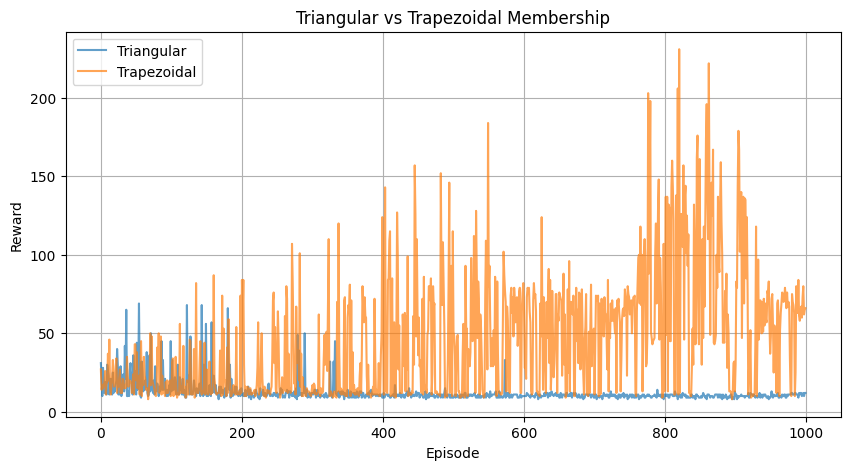

In [17]:
# TRIANGULAR VS TRAPEZOIDAL MEMBERSHIP

rewards_triangular = train(
    episodes=1000,
    num_sets=3,
    membership_type="triangular",
    alpha=0.1,
    gamma=0.9
)

rewards_trapezoidal = train(
    episodes=1000,
    num_sets=3,
    membership_type="trapezoidal",
    alpha=0.1,
    gamma=0.9
)

plt.figure(figsize=(10, 5))
plt.plot(rewards_triangular, label="Triangular", alpha=0.7)
plt.plot(rewards_trapezoidal, label="Trapezoidal", alpha=0.7)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Triangular vs Trapezoidal Membership")
plt.legend()
plt.grid()
plt.show()

Running alpha = 0.01
Episode 100, Average Reward = 19.31, Epsilon = 0.606
Episode 200, Average Reward = 15.81, Epsilon = 0.367
Episode 300, Average Reward = 12.23, Epsilon = 0.222
Episode 400, Average Reward = 10.72, Epsilon = 0.135
Episode 500, Average Reward = 10.29, Epsilon = 0.082
Episode 600, Average Reward = 9.96, Epsilon = 0.049
Episode 700, Average Reward = 9.86, Epsilon = 0.030
Episode 800, Average Reward = 9.67, Epsilon = 0.018
Episode 900, Average Reward = 9.84, Epsilon = 0.011
Episode 1000, Average Reward = 9.73, Epsilon = 0.010
Running alpha = 0.05
Episode 100, Average Reward = 20.42, Epsilon = 0.606
Episode 200, Average Reward = 15.23, Epsilon = 0.367
Episode 300, Average Reward = 13.02, Epsilon = 0.222
Episode 400, Average Reward = 11.75, Epsilon = 0.135
Episode 500, Average Reward = 10.88, Epsilon = 0.082
Episode 600, Average Reward = 10.51, Epsilon = 0.049
Episode 700, Average Reward = 10.55, Epsilon = 0.030
Episode 800, Average Reward = 10.29, Epsilon = 0.018
Episode 

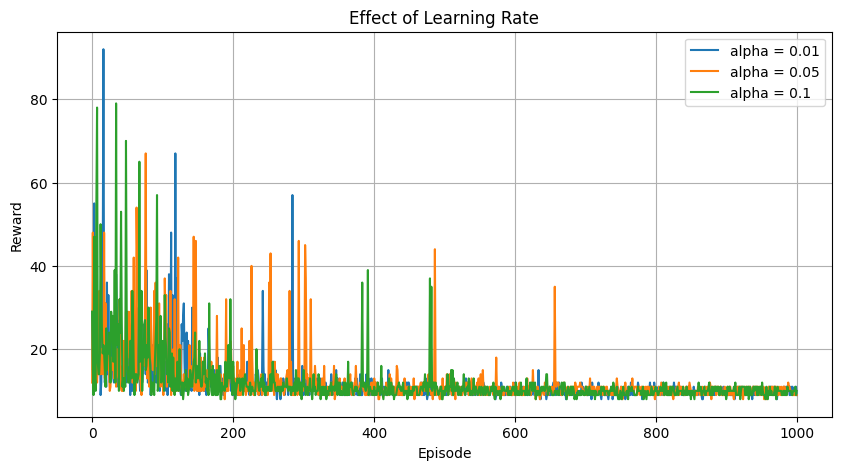

In [18]:
# EFFECT OF LEARNING RATE (ALPHA)

alphas = [0.01, 0.05, 0.1]
alpha_results = {}

for alpha in alphas:
    print("Running alpha =", alpha)
    alpha_results[alpha] = train(
        episodes=1000,
        num_sets=3,
        membership_type="triangular",
        alpha=alpha,
        gamma=0.9
    )

plt.figure(figsize=(10, 5))

for alpha in alphas:
    plt.plot(
        alpha_results[alpha],
        label=f"alpha = {alpha}"
    )

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Effect of Learning Rate")
plt.legend()
plt.grid()
plt.show()

Running gamma = 0.5
Episode 100, Average Reward = 20.97, Epsilon = 0.606
Episode 200, Average Reward = 15.23, Epsilon = 0.367
Episode 300, Average Reward = 12.05, Epsilon = 0.222
Episode 400, Average Reward = 11.54, Epsilon = 0.135
Episode 500, Average Reward = 10.76, Epsilon = 0.082
Episode 600, Average Reward = 10.13, Epsilon = 0.049
Episode 700, Average Reward = 10.51, Epsilon = 0.030
Episode 800, Average Reward = 10.04, Epsilon = 0.018
Episode 900, Average Reward = 10.03, Epsilon = 0.011
Episode 1000, Average Reward = 9.94, Epsilon = 0.010
Running gamma = 0.9
Episode 100, Average Reward = 18.65, Epsilon = 0.606
Episode 200, Average Reward = 13.47, Epsilon = 0.367
Episode 300, Average Reward = 12.15, Epsilon = 0.222
Episode 400, Average Reward = 11.58, Epsilon = 0.135
Episode 500, Average Reward = 10.72, Epsilon = 0.082
Episode 600, Average Reward = 10.16, Epsilon = 0.049
Episode 700, Average Reward = 10.23, Epsilon = 0.030
Episode 800, Average Reward = 10.14, Epsilon = 0.018
Episod

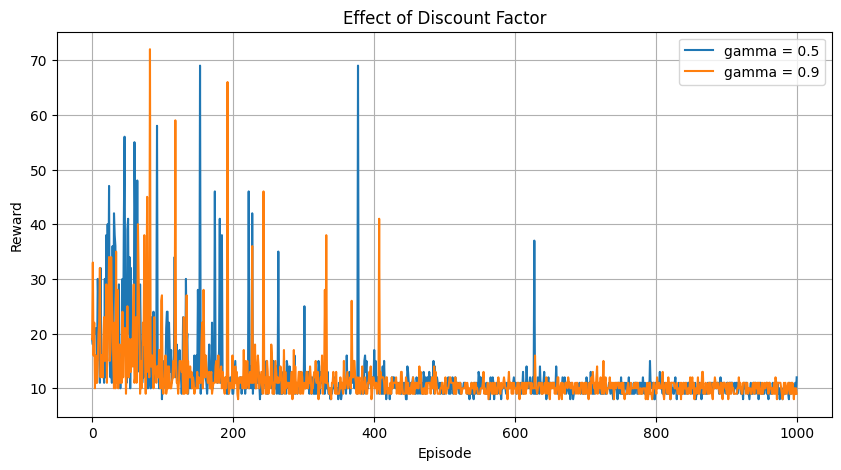

In [19]:
# EFFECT OF DISCOUNT FACTOR (GAMMA)

gammas = [0.5, 0.9]
gamma_results = {}

for gamma in gammas:
    print("Running gamma =", gamma)
    gamma_results[gamma] = train(
        episodes=1000,
        num_sets=3,
        membership_type="triangular",
        alpha=0.1,
        gamma=gamma
    )

plt.figure(figsize=(10, 5))

for gamma in gammas:
    plt.plot(
        gamma_results[gamma],
        label=f"gamma = {gamma}"
    )

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Effect of Discount Factor")
plt.legend()
plt.grid()
plt.show()